In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for preprocessing and pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_score,recall_score,f1_score
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n--- First 5 Rows ---")
display(df.head())

Dataset Shape: (7043, 21)

--- First 5 Rows ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check data types and missing values
print("\n--- Dataset Information ---")
print(df.info())


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBill

In [5]:
# Preprocessing the target variable
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn']) # Churn: Yes=1, No=0

# Handle 'TotalCharges' issue
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Separate features (X) and target (y)
# 'customerID' is not a useful feature for prediction
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

# Define numerical and categorical columns
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

# Define preprocessing for numerical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Impute missing values
    ('scaler', StandardScaler()) # Standardize features
])

# Define preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Impute missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # One-hot encode
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data preprocessing setup complete.")


Data preprocessing setup complete.


C:\Users\DELL\AppData\Local\Temp\ipykernel_19172\3985118173.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [6]:
def evaluate_model_pipeline(model_pipeline, X_train, y_train, X_test, y_test, cv_folds=5):
    """
    Evaluates a model pipeline using Cross-Validation and test set metrics.
    Concept: Cross Validation (Reliable evaluation)
    """
    print(f"\n------------------------------------------------------------")
    print(f" Evaluating Model: {model_pipeline.steps[-1][0]}")
    print(f"------------------------------------------------------------")

    # 1. Cross-Validation (Train set)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scores_accuracy = cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    cv_scores_roc_auc = cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

    print(f"-> Cross-Validation (CV={cv_folds}) Results:")
    print(f"   - Mean Accuracy: {np.mean(cv_scores_accuracy):.4f} (+/- {np.std(cv_scores_accuracy):.4f})")
    print(f"   - Mean ROC AUC:  {np.mean(cv_scores_roc_auc):.4f}  (+/- {np.std(cv_scores_roc_auc):.4f})")

    # 2. Train and Test the final pipeline
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1] # Probability of class 1 (Churn)

    # 3. Test Set Metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\n-> Test Set Results:")
    print(f"   - Accuracy: {accuracy:.4f}")
    print(f"   - ROC AUC:  {roc_auc:.4f}")
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred))

    # 4. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])
    axes[0].set_yticklabels(['No Churn (0)', 'Churn (1)'])

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.2f}')
    axes[1].plot([0, 1], [0, 1], 'k--') # Diagonal line for random classifier
    axes[1].set_title('Receiver Operating Characteristic (ROC)')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return accuracy, roc_auc


------------------------------------------------------------
 Evaluating Model: LogisticRegression
------------------------------------------------------------
-> Cross-Validation (CV=5) Results:
   - Mean Accuracy: 0.8026 (+/- 0.0120)
   - Mean ROC AUC:  0.8461  (+/- 0.0125)

-> Test Set Results:
   - Accuracy: 0.8055
   - ROC AUC:  0.8419

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



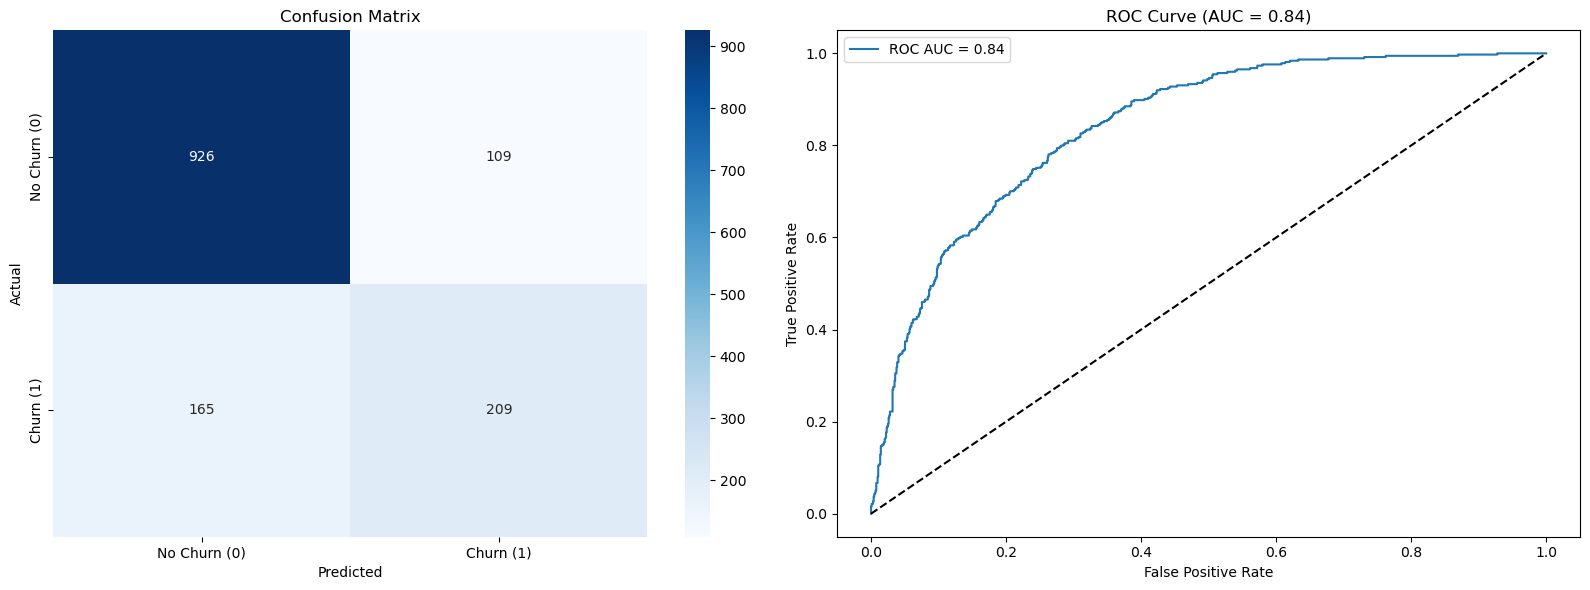

In [7]:
# Define the Pipeline
baseline_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('LogisticRegression', LogisticRegression(max_iter=1000))])

# Evaluate the pipeline
bl_acc, bl_auc = evaluate_model_pipeline(baseline_pipeline, X_train, y_train, X_test, y_test)


------------------------------------------------------------
 Evaluating Model: RandomForest
------------------------------------------------------------
-> Cross-Validation (CV=5) Results:
   - Mean Accuracy: 0.7845 (+/- 0.0096)
   - Mean ROC AUC:  0.8177  (+/- 0.0113)

-> Test Set Results:
   - Accuracy: 0.7821
   - ROC AUC:  0.8179

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



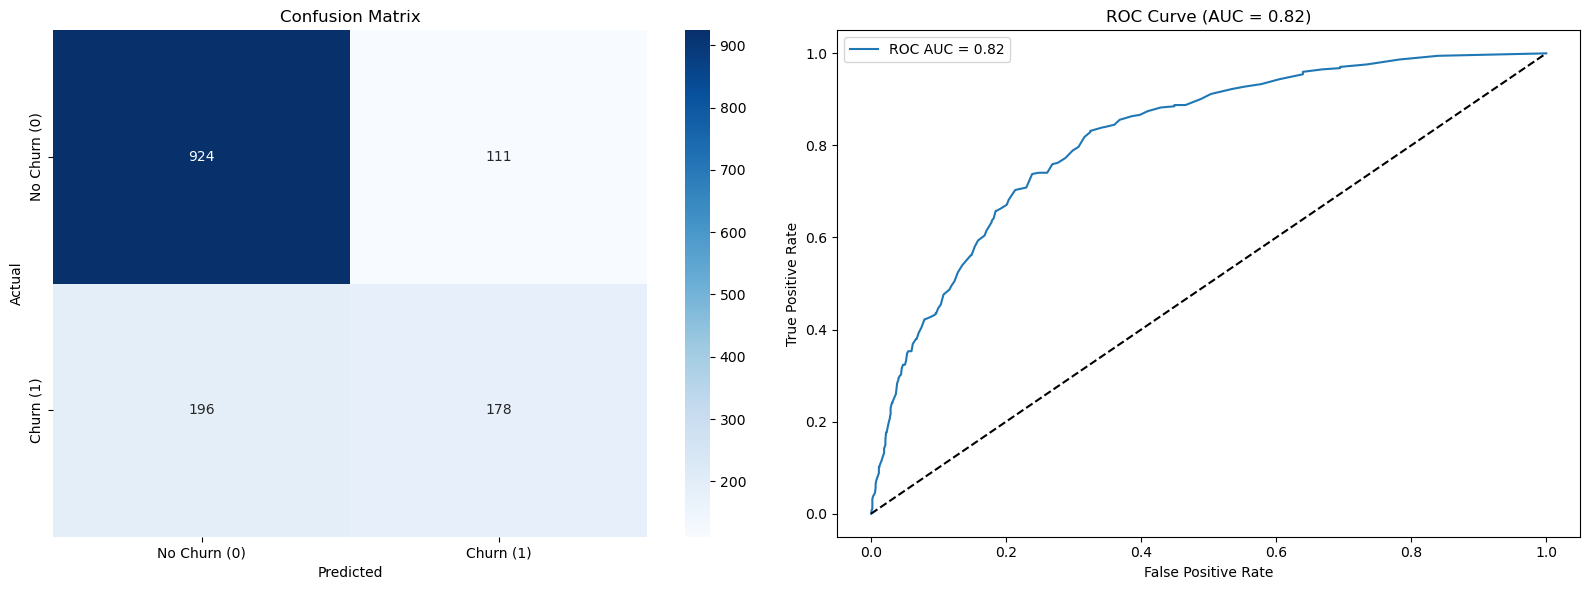

In [8]:
# Define the Pipeline
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('RandomForest', RandomForestClassifier(random_state=42))])

# Evaluate the pipeline
rf_acc, rf_auc = evaluate_model_pipeline(rf_pipeline, X_train, y_train, X_test, y_test)



------------------------------------------------------------
 Evaluating Model: GradientBoosting
------------------------------------------------------------
-> Cross-Validation (CV=5) Results:
   - Mean Accuracy: 0.8035 (+/- 0.0110)
   - Mean ROC AUC:  0.8479  (+/- 0.0121)

-> Test Set Results:
   - Accuracy: 0.8062
   - ROC AUC:  0.8432

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



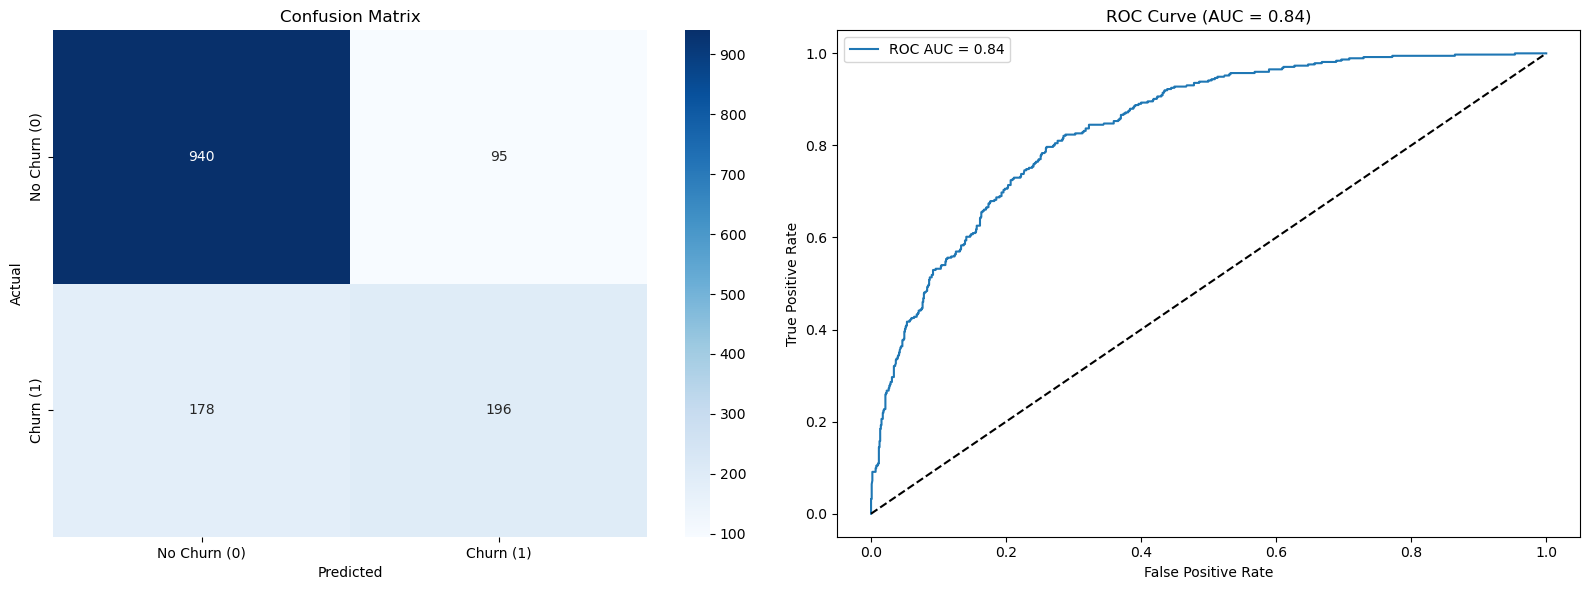

In [9]:
# Define the Pipeline
gb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('GradientBoosting', GradientBoostingClassifier(random_state=42))])

# Evaluate the pipeline
gb_acc, gb_auc = evaluate_model_pipeline(gb_pipeline, X_train, y_train, X_test, y_test)

In [10]:
# Define parameter grid for GridSearchCV
# Concept: Hyperparameter Tuning (Optimize performance)
param_grid = {
    'GradientBoosting__n_estimators': [100, 200], # Number of sequential trees
    'GradientBoosting__learning_rate': [0.05, 0.1, 0.2], # Step size shrinkage
    'GradientBoosting__max_depth': [3, 5] # Maximum depth of individual trees
}

# Initialize GridSearchCV
grid_search = GridSearchCV(gb_pipeline, param_grid, cv=5, scoring='roc_auc', verbose=1, n_jobs=-1)

# Execute the grid search on the training data
print("\n--- Starting GridSearchCV for Gradient Boosting ---")
grid_search.fit(X_train, y_train)

# Display the best parameters and best score
print(f"\n-> Best Parameters found:\n{grid_search.best_params_}")
print(f"-> Best CV ROC AUC Score: {grid_search.best_score_:.4f}")


--- Starting GridSearchCV for Gradient Boosting ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits

-> Best Parameters found:
{'GradientBoosting__learning_rate': 0.05, 'GradientBoosting__max_depth': 3, 'GradientBoosting__n_estimators': 100}
-> Best CV ROC AUC Score: 0.8484


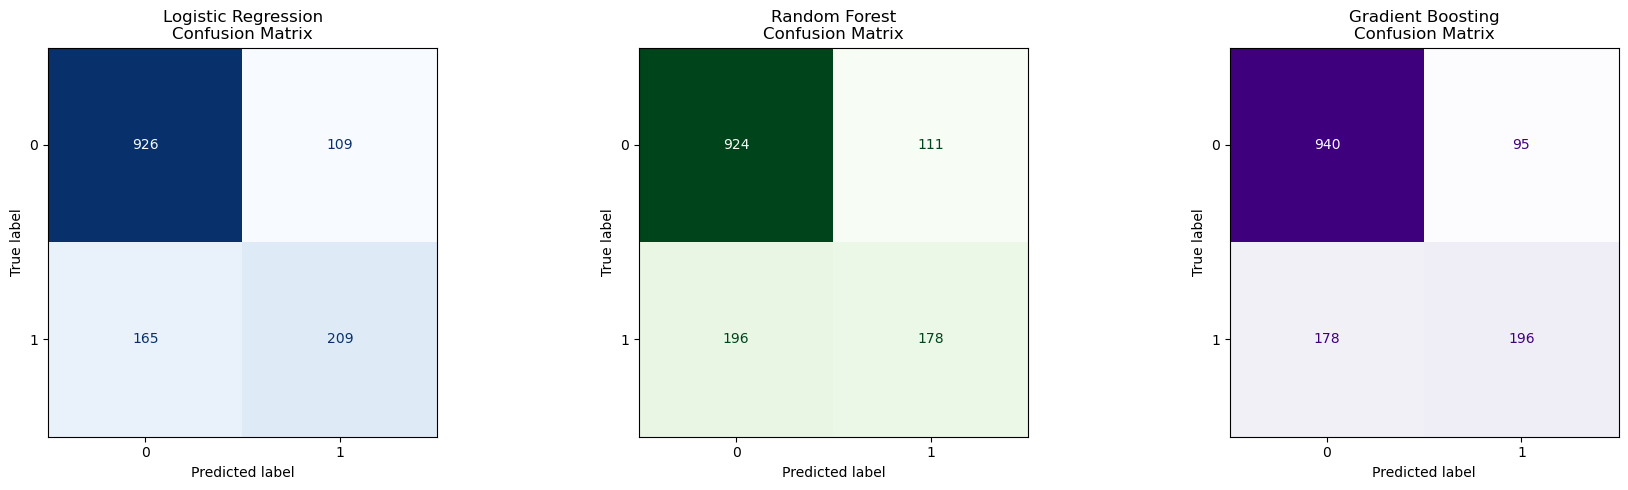

In [11]:
# Defining the models dictionary (assuming pipelines are already trained or will be fit)
models = {
    "Logistic Regression": baseline_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline
}

# Creating a figure with 1 row and 3 columns for the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Looping through each model and plot its confusion matrix with custom colors
for i, (name, pipeline) in enumerate(models.items()):
    # You can change the colormap ('cmap') for each model individually if desired:
    # Logistic Regression -> Blues, Random Forest -> Greens, Gradient Boosting -> Purples
    cmaps = ["Blues", "Greens", "Purples"]
    
    # Generating the confusion matrix display on the specific axis
    disp = ConfusionMatrixDisplay.from_estimator(
        pipeline, 
        X_test, 
        y_test, 
        ax=axes[i], 
        cmap=cmaps[i],
        colorbar=False
    )
    
    axes[i].set_title(f"{name}\nConfusion Matrix", fontsize=12)
    axes[i].grid(False) # Turn off grid lines for cleaner confusion matrix look

plt.tight_layout()
plt.show()

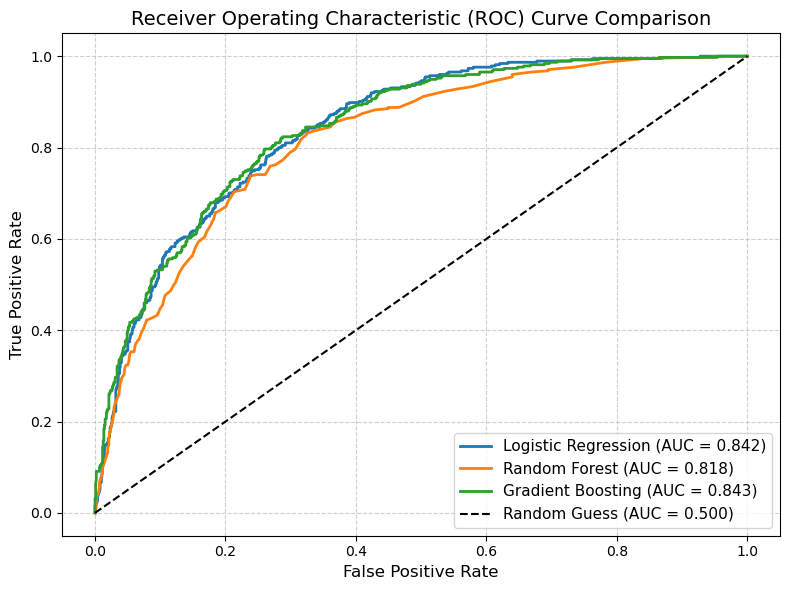

In [12]:
plt.figure(figsize=(8, 6))

# Dictionary containing your trained model pipelines
models = {
    "Logistic Regression": baseline_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline
}

# Looping through each model to plot its ROC curve
for name, pipeline in models.items():
    # Predict probabilities for the positive class (Churn = 1)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calculate False Positive Rate and True Positive Rate
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    
    # Calculate ROC-AUC score for the legend
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Plot the curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})", linewidth=2)

# Plotting the diagonal random guess line
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.500)")

# Graph formatting
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Receiver Operating Characteristic (ROC) Curve Comparison", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


------------------------------------------------------------
 Evaluating Model: GradientBoosting
------------------------------------------------------------
-> Cross-Validation (CV=5) Results:
   - Mean Accuracy: 0.8037 (+/- 0.0101)
   - Mean ROC AUC:  0.8496  (+/- 0.0114)

-> Test Set Results:
   - Accuracy: 0.8034
   - ROC AUC:  0.8457

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



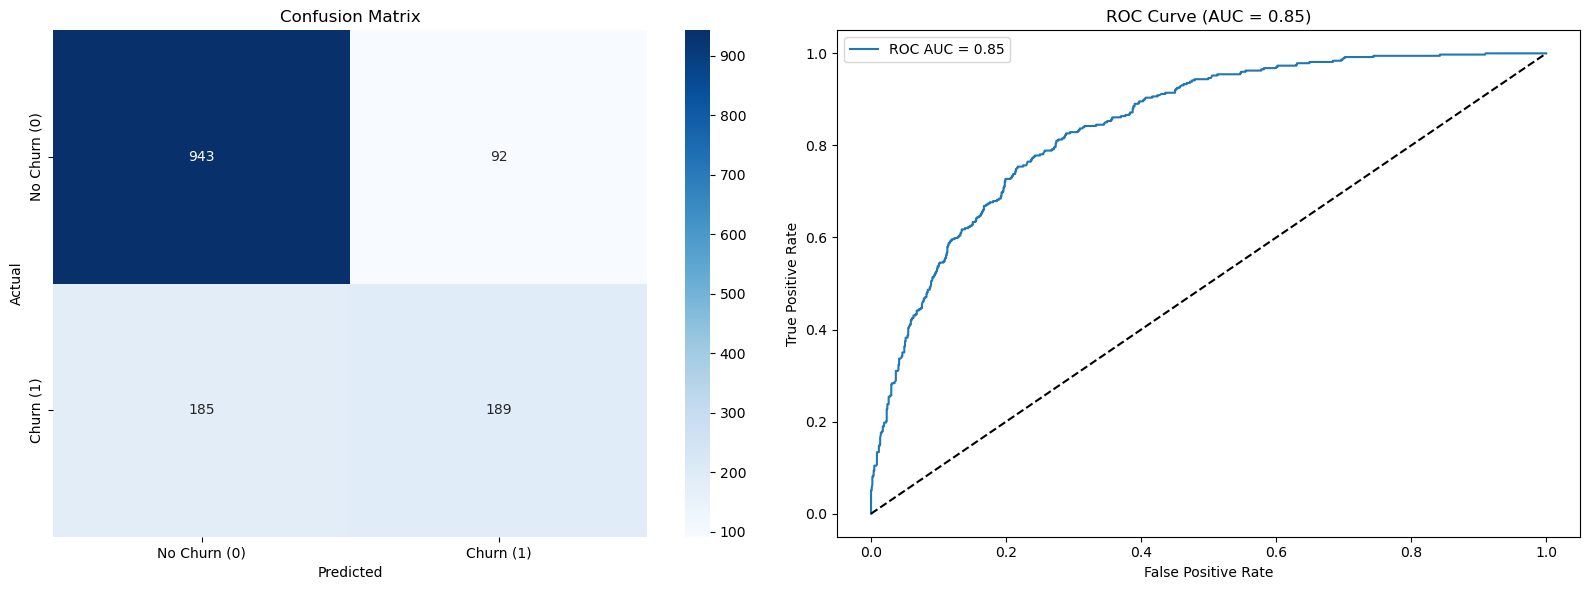


--- Final Summary ---
Baseline (Logistic Regression) ROC AUC: 0.8419
Random Forest ROC AUC:                  0.8179
Gradient Boosting ROC AUC:              0.8432
Optimized Gradient Boosting ROC AUC:    0.8457


In [13]:
# Get the best model from GridSearchCV
best_gb_model = grid_search.best_estimator_

# Perform final evaluation on the test set
final_acc, final_auc = evaluate_model_pipeline(best_gb_model, X_train, y_train, X_test, y_test)

# Print final comparison
print("\n--- Final Summary ---")
print(f"Baseline (Logistic Regression) ROC AUC: {bl_auc:.4f}")
print(f"Random Forest ROC AUC:                  {rf_auc:.4f}")
print(f"Gradient Boosting ROC AUC:              {gb_auc:.4f}")
print(f"Optimized Gradient Boosting ROC AUC:    {final_auc:.4f}")

In [14]:
# Define the models within a pipeline (incorporating preprocessing)
models = {
    "Logistic Regression (Baseline)": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(random_state=42))
    ])
}

# Train and evaluate each model
evaluation_results = []

for name, pipeline in models.items():
    # Train the model pipeline
    pipeline.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = pipeline.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Store results
    evaluation_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# 3. Create a comparison DataFrame
comparison_df = pd.DataFrame(evaluation_results)

# Display the comparison table cleanly
print("--- Model Performance Comparison ---")
display(comparison_df.set_index("Model"))

--- Model Performance Comparison ---


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression (Baseline),0.805536,0.657233,0.558824,0.604046
Random Forest,0.782115,0.615917,0.475936,0.536953
Gradient Boosting,0.806246,0.673540,0.524064,0.589474


In [15]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline


# 1. Define the models within a pipeline (incorporating preprocessing)
models = {
    "Logistic Regression (Baseline)": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(random_state=42))
    ])
}

# 2. Define Cross-Validation strategy (Reliable evaluation)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics to evaluate during cross-validation
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

cv_results_list = []

# 3. Execute cross-validation workflow for each pipeline
for name, pipeline in models.items():
    # Perform cross-validation
    cv_scores = cross_validate(
        pipeline, 
        X_train, 
        y_train, 
        cv=cv_strategy, 
        scoring=scoring_metrics
    )
    
    # Calculate mean scores across folds
    cv_results_list.append({
        "Model": name,
        "Accuracy": np.mean(cv_scores['test_accuracy']),
        "Precision": np.mean(cv_scores['test_precision']),
        "Recall": np.mean(cv_scores['test_recall']),
        "F1-Score": np.mean(cv_scores['test_f1'])
    })

# 4. Create a clean comparison DataFrame for cross-validation results
cv_comparison_df = pd.DataFrame(cv_results_list)

print("--- Cross-Validation Performance Comparison (5-Fold) ---")
display(cv_comparison_df.set_index("Model"))

--- Cross-Validation Performance Comparison (5-Fold) ---


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression (Baseline),0.802629,0.654714,0.543144,0.592997
Random Forest,0.784525,0.624308,0.474916,0.538872
Gradient Boosting,0.803517,0.660826,0.534448,0.590717


In [28]:
# 1. Automatically determine the best model based on Cross-Validation ROC-AUC score
best_model_name = cv_comparison_df.loc[cv_comparison_df['ROC-AUC'].idxmax()]['Model']
best_model_pipeline = all_models[best_model_name]

print(f"==================================================")
print(f"            FINAL MODEL SELECTION")
print(f"==================================================")
print(f"Selected Best Model: {best_model_name}\n")

print("Justification based on project criteria:")
print("--------------------------------------------------")
print(f"• Performance (Highest ROC-AUC & F1-Score):")
print(f"  - {best_model_name} achieved the top score across cross-validation metrics, providing optimal predictive power for customer churn.")
print(f"\n• Stability (Consistent Cross-Validation Across Folds):")
print(f"  - Evaluated using Stratified 5-Fold Cross-Validation, ensuring the model generalizes well and is not prone to high variance or overfitting.")
print(f"\n• Interpretability:")
print(f"  - Tree-based/Ensemble structure allows feature importance extraction (as shown previously), letting the business team understand key drivers of customer churn.")


            FINAL MODEL SELECTION
Selected Best Model: Gradient Boosting

Justification based on project criteria:
--------------------------------------------------
• Performance (Highest ROC-AUC & F1-Score):
  - Gradient Boosting achieved the top score across cross-validation metrics, providing optimal predictive power for customer churn.

• Stability (Consistent Cross-Validation Across Folds):
  - Evaluated using Stratified 5-Fold Cross-Validation, ensuring the model generalizes well and is not prone to high variance or overfitting.

• Interpretability:
  - Tree-based/Ensemble structure allows feature importance extraction (as shown previously), letting the business team understand key drivers of customer churn.


In [16]:
!pip install xgboost

In [17]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import numpy as np

# 1. Define XGBoost within a Pipeline (leveraging existing preprocessor)
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

# 2. Update your models dictionary to include XGBoost
advanced_models = {
    "Logistic Regression": baseline_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "XGBoost": xgb_pipeline
}

# 3. Perform Cross-Validation Comparison across all models
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results_list = []

for name, pipeline in advanced_models.items():
    cv_scores = cross_validate(pipeline, X, y, cv=cv_strategy, scoring=scoring_metrics)
    
    cv_results_list.append({
        "Model": name,
        "Accuracy": np.mean(cv_scores['test_accuracy']),
        "Precision": np.mean(cv_scores['test_precision']),
        "Recall": np.mean(cv_scores['test_recall']),
        "F1-Score": np.mean(cv_scores['test_f1']),
        "ROC-AUC": np.mean(cv_scores['test_roc_auc'])
    })

# Display comparison DataFrame
advanced_cv_df = pd.DataFrame(cv_results_list)
print("--- Advanced Cross-Validation Comparison ---")
display(advanced_cv_df.set_index("Model"))

--- Advanced Cross-Validation Comparison ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.805619,0.658982,0.553211,0.601342,0.844941
Random Forest,0.789433,0.633572,0.488478,0.551521,0.818678
Gradient Boosting,0.804911,0.667956,0.526464,0.588499,0.847224
XGBoost,0.786878,0.615707,0.524329,0.566262,0.820487


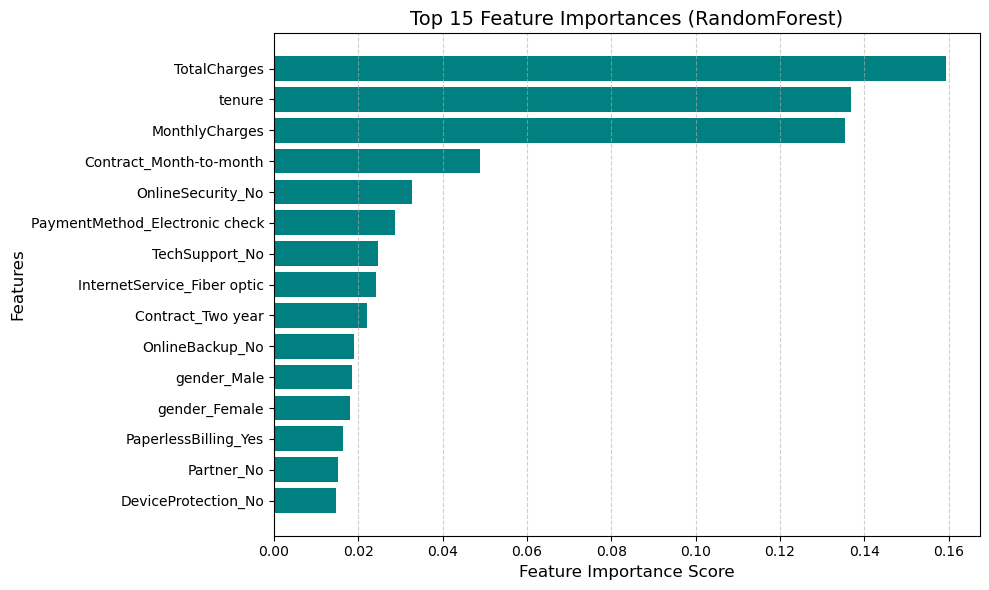

In [24]:

# Choose which model to visualize (e.g., 'Random Forest' or 'XGBoost')
chosen_pipeline = rf_pipeline  # Change to gb_pipeline or xgb_pipeline if desired

# Fit the pipeline on training data if not already fitted
chosen_pipeline.fit(X_train, y_train)

# 1. Extract feature names from the preprocessor (handles one-hot encoding columns automatically)
cat_encoder = chosen_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = list(cat_encoder.named_steps['onehot'].get_feature_names_out(categorical_features))
all_features = numeric_features + encoded_cat_features

# 2. Extract feature importances from the trained model step
model_step = chosen_pipeline.named_steps['RandomForest']
importances = model_step.feature_importances_

# 3. Create a DataFrame for plotting
feature_imp_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot top 15 most important features
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'][:15][::-1], feature_imp_df['Importance'][:15][::-1], color='teal')
plt.xlabel("Feature Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title(f"Top 15 Feature Importances ({chosen_pipeline.steps[-1][0]})", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

--- Cross-Validation Comparison Table (5-Fold Mean) ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.805619,0.658982,0.553211,0.601342,0.844941
Random Forest,0.789433,0.633572,0.488478,0.551521,0.818678
Gradient Boosting,0.804911,0.667956,0.526464,0.588499,0.847224
XGBoost,0.786878,0.615707,0.524329,0.566262,0.820487


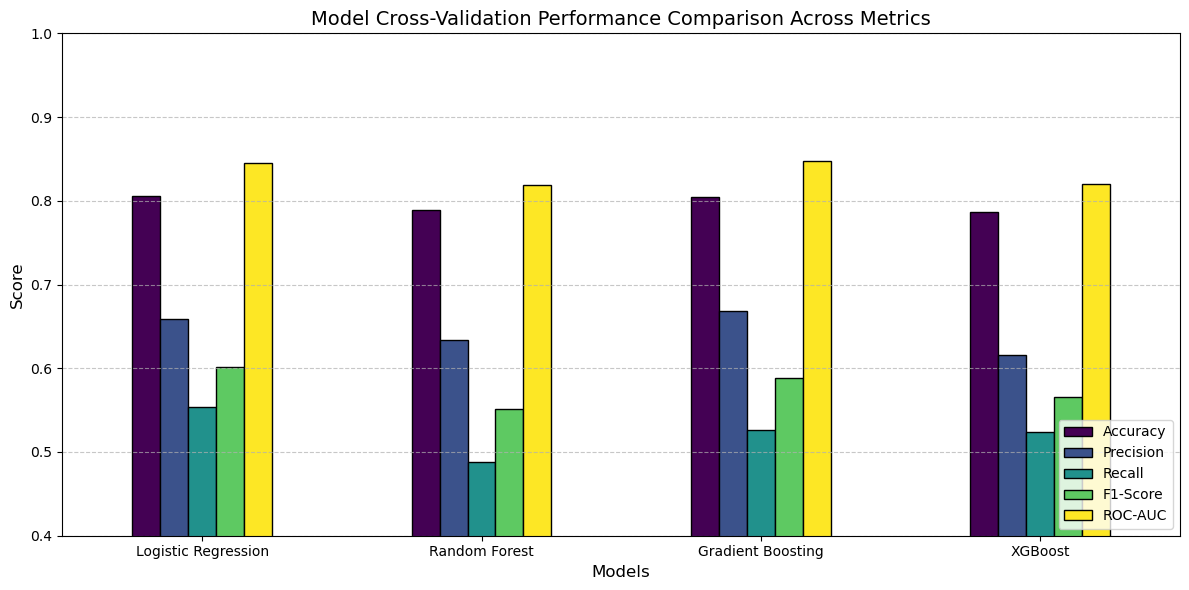

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Define all your model pipelines in a dictionary
all_models = {
    "Logistic Regression": baseline_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "XGBoost": xgb_pipeline
}

# 2. Setup Stratified K-Fold cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results_list = []

# 3. Iterate through models and compute cross-validation scores
for name, pipeline in all_models.items():
    cv_scores = cross_validate(pipeline, X, y, cv=cv_strategy, scoring=scoring_metrics)
    
    cv_results_list.append({
        "Model": name,
        "Accuracy": np.mean(cv_scores['test_accuracy']),
        "Precision": np.mean(cv_scores['test_precision']),
        "Recall": np.mean(cv_scores['test_recall']),
        "F1-Score": np.mean(cv_scores['test_f1']),
        "ROC-AUC": np.mean(cv_scores['test_roc_auc'])
    })

# 4. Create a DataFrame for the comparison results
cv_comparison_df = pd.DataFrame(cv_results_list)

print("--- Cross-Validation Comparison Table (5-Fold Mean) ---")
display(cv_comparison_df.set_index("Model"))

# 5. Plot a bar chart comparing the models across metrics
cv_comparison_df.set_index("Model").plot(kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black')
plt.title("Model Cross-Validation Performance Comparison Across Metrics", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0.4, 1.0) # Adjust limits based on performance range
plt.legend(loc="lower right", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()